In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
from PIL import Image
from keras.preprocessing.image import load_img

: 

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D,Input
from tensorflow.keras.utils import plot_model
from pathlib import Path
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform,glorot_uniform,constant,identity
from tensorflow.keras.layers import Add,BatchNormalization,GlobalMaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import datasets,layers,models

In [4]:
BASE_DIRS = [r'/kaggle/input/datasets/jangedoo/utkface-new/UTKFace']

In [5]:
image_paths = []
age_labels = []
gender_paths = []

In [6]:
from tqdm.notebook import tqdm

In [7]:
for BASE_DIR in BASE_DIRS:
    for filename in tqdm(os.listdir(BASE_DIR)):
        temp = filename.split('_')
        if temp[0].isdigit():
            age = int(temp[0])
            gender = int(temp[1])
            image_path = os.path.join(BASE_DIR, filename)
            image_paths.append(image_path)
            age_labels.append(age)
            gender_paths.append(gender)

  0%|          | 0/23708 [00:00<?, ?it/s]

In [8]:
df = pd.DataFrame()
df['image'],df['age'],df['gender'] = image_paths,age_labels,gender_paths
df.head()

,image,age,gender
0,/kaggle/input/datasets/jangedoo/utkface-new/UT...,26,0
1,/kaggle/input/datasets/jangedoo/utkface-new/UT...,22,1
2,/kaggle/input/datasets/jangedoo/utkface-new/UT...,21,1
3,/kaggle/input/datasets/jangedoo/utkface-new/UT...,28,0
4,/kaggle/input/datasets/jangedoo/utkface-new/UT...,17,1


In [9]:
print(f"DataFrame:{df}")
print(f"DataFrame shape:{df.shape}")
print(f"first few rows of the dataframe:{df.head()}")

DataFrame:                                                   image  age  gender
0      /kaggle/input/datasets/jangedoo/utkface-new/UT...   26       0
1      /kaggle/input/datasets/jangedoo/utkface-new/UT...   22       1
2      /kaggle/input/datasets/jangedoo/utkface-new/UT...   21       1
3      /kaggle/input/datasets/jangedoo/utkface-new/UT...   28       0
4      /kaggle/input/datasets/jangedoo/utkface-new/UT...   17       1
...                                                  ...  ...     ...
23703  /kaggle/input/datasets/jangedoo/utkface-new/UT...   41       0
23704  /kaggle/input/datasets/jangedoo/utkface-new/UT...   42       0
23705  /kaggle/input/datasets/jangedoo/utkface-new/UT...    2       0
23706  /kaggle/input/datasets/jangedoo/utkface-new/UT...   65       1
23707  /kaggle/input/datasets/jangedoo/utkface-new/UT...   66       0

[23708 rows x 3 columns]
DataFrame shape:(23708, 3)
first few rows of the dataframe:                                               image  age  gender

In [10]:
gender_dict = {0:'Male',1:'Female'}


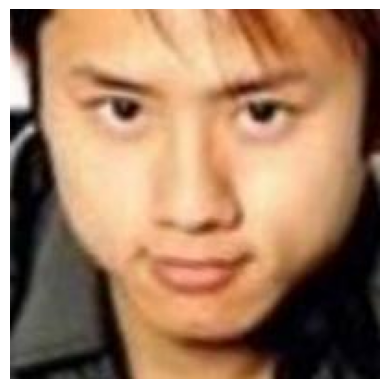

In [11]:
if not df.empty:
    try:
        img=Image.open(df['image'][0])
        plt.axis('off')
        plt.imshow(img)
        plt.show()
    except Exception as e:
        print(f"Error opening image:{e}")
else:
    print(f"Dataframe is empty, no images found.")

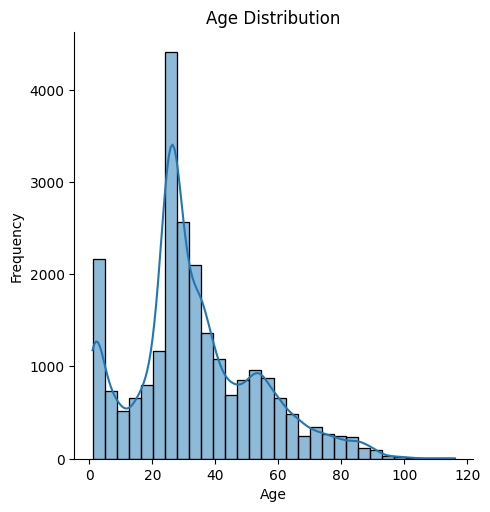

In [12]:
sns.displot(df['age'],kde=True,bins=30)
plt.title("Age Distribution")
plt.xlabel('Age')
plt.ylabel("Frequency")
plt.show()

In [13]:
def extract_feature(images):
    features =[]
    for image in tqdm(images):
        img = Image.open(image).convert('L')
        img=img.resize((128,128),Image.BILINEAR)
        img=np.array(img)
        features.append(img)
    features=np.array(features)
    features = features.reshape(len(features),128,128,1)
    return features

In [14]:
x = extract_feature(df['image'])
print(f"X_shape:\t{x.shape}")

  0%|          | 0/23708 [00:00<?, ?it/s]

X_shape:	(23708, 128, 128, 1)


In [15]:
x = x/255.0
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])
print("shape of y_gender:",y_gender.shape)
print("shape of y_age:",y_age.shape)


shape of y_gender: (23708,)
shape of y_age: (23708,)


In [20]:

input_shape = (128,128,1)
inputs = Input(input_shape)

conv1 = Conv2D(32,kernel_size=(3,3),activation='relu')(inputs)
maxp1 = MaxPooling2D(pool_size=(2,2))(conv1)
conv2 = Conv2D(64,kernel_size=(3,3),activation='relu')(maxp1)
maxp2 = MaxPooling2D(pool_size=(2,2))(conv2)
conv3 = Conv2D(128,kernel_size=(3,3),activation='relu')(maxp2)
maxp3 = MaxPooling2D(pool_size=(2,2))(conv3)
conv4 = Conv2D(256,kernel_size=(3,3),activation='relu')(maxp3)
maxp4 = MaxPooling2D(pool_size=(2,2))(conv4)
flatten = Flatten()(maxp4)
dense1 = Dense(256,activation='relu')(flatten)
dense2 = Dense(256,activation='relu')(flatten)
dropout1 = Dropout(0.5)(dense1)
dropout2 = Dropout(0.5)(dense2)

output1 = Dense(1,activation='sigmoid',name = 'gender_out')(dropout1)
output2 = Dense(1,activation='relu',name = 'age_out')(dropout2)

model = Model(inputs=inputs,outputs=[output1,output2])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 126, 126,  │        320 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 63, 63,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 30, 30,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 12, 12,    │    295,168 │ max_pooling2d_6[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 6, 6, 256) │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 9216)      │          0 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  2,359,552 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │  2,359,552 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 1)         │        257 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │        257 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,107,458 (19.48 MB)

 Trainable params: 5,107,458 (19.48 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
y_combined = np.column_stack((y_gender,y_age))
X_train,X_temp,y_combined_train,y_combined_temp=train_test_split(
    x,y_combined,test_size=0.2,random_state=42
)
x_test,x_val,y_combined_test,y_combined_val= train_test_split(X_temp,y_combined_temp,test_size=0.5,random_state=42)

In [22]:
y_train_gender,y_train_age = y_combined_train[:,0],y_combined_train[:,1]
y_test_gender, y_test_age = y_combined_test[:,0], y_combined_test[:,1]
y_val_gender, y_val_age = y_combined_val[:,0], y_combined_val[:,1]

In [23]:
model_path = './best_model.keras'
checkpointer = ModelCheckpoint(
    filepath = model_path,
    monitor = 'val_gender_out_accuracy',
    verbose = 1,
    mode = 'max',
    save_best_only = True
)
    

In [24]:
from keras.callbacks import LearningRateScheduler
model.compile(loss=['binary_crossentropy','mae'],
             optimizer='adam',
             metrics=['accuracy','mae'])
annealer = LearningRateScheduler(lambda x:1e-3*0.9**x)

In [25]:
total_images = len(image_paths)
print(f'total number of images:{total_images}s')

total number of images:23708s


In [26]:
train_images =len(X_train)
val_images= len(x_val)
test_images = len(x_test)
print(f"Number of the training images:{train_images}")
print(f"Number of val images:{val_images}")
print(f"Number of test images:{test_images}")

Number of the training images:18966
Number of val images:2371
Number of test images:2371


In [29]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [30]:
history = model.fit(
    x = X_train,
    y = [y_train_gender,y_train_age],
    batch_size = 128,
    epochs = 100,
    validation_data = (x_val,[y_val_gender,y_val_age]),
    callbacks = [annealer,checkpointer]
)

Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - age_out_loss: 10.7813 - age_out_mae: 10.7813 - gender_out_accuracy: 0.7714 - gender_out_loss: 0.4846 - loss: 11.2659
Epoch 1: val_gender_out_accuracy improved from 0.73176 to 0.78828, saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 28s 165ms/step - age_out_loss: 10.7803 - age_out_mae: 10.7803 - gender_out_accuracy: 0.7715 - gender_out_loss: 0.4845 - loss: 11.2648 - val_age_out_loss: 10.3090 - val_age_out_mae: 10.3090 - val_gender_out_accuracy: 0.7883 - val_gender_out_loss: 0.4430 - val_loss: 10.7520 - learning_rate: 0.0010
Epoch 2/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - age_out_loss: 10.0433 - age_out_mae: 10.0433 - gender_out_accuracy: 0.7950 - gender_out_loss: 0.4471 - loss: 10.4905
Epoch 2: val_gender_out_accuracy improved from 0.78828 to 0.80388, saving model to ./best_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 23s 158ms/step - age_out_loss: 10.0421 - age_out_mae: 10.0421 - gender_out_accuracy: 0.7950 -

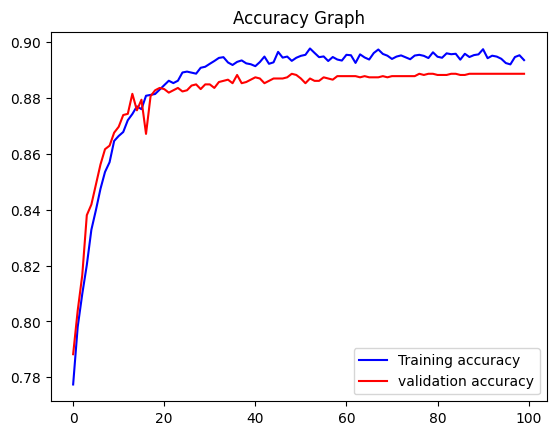

In [31]:
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))
plt.plot(epochs,acc,'b',label='Training accuracy')
plt.plot(epochs,val_acc,'r',label='validation accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.show()

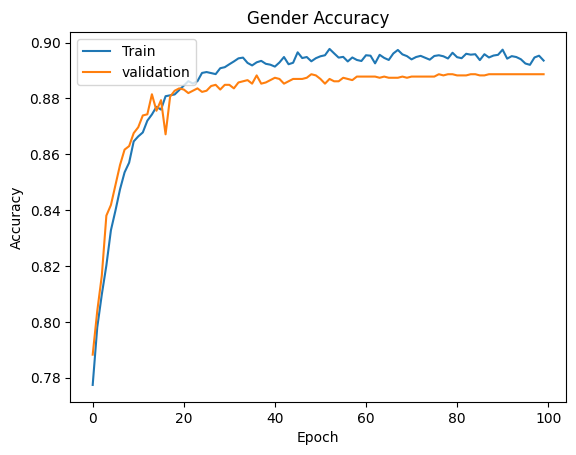

In [32]:
plt.plot(history.history['gender_out_accuracy'])
plt.plot(history.history['val_gender_out_accuracy'])
plt.title('Gender Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','validation'],loc='upper left')
plt.show()

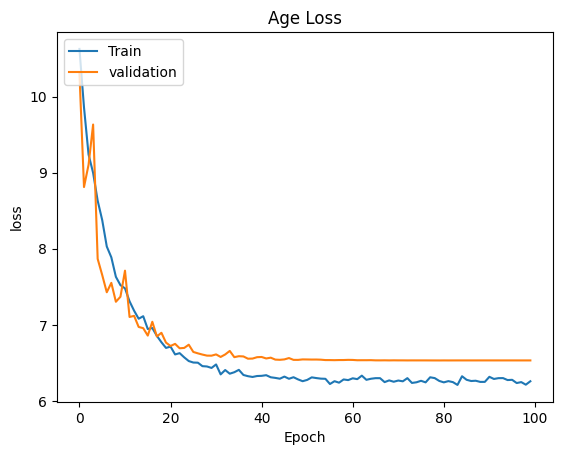

In [33]:
plt.plot(history.history['age_out_mae'])
plt.plot(history.history['val_age_out_mae'])
plt.title('Age Loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train','validation'],loc='upper left')
plt.show()

In [39]:
image_index = 3000
print(f"original gender:\t{gender_dict[y_gender[image_index]]}\t original Age:\t{y_age[image_index]}")

original gender:	Male	 original Age:	28


In [40]:
pred = model.predict(x[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]
pred_age = round(pred[1][0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


Predicted gender:	 Male	 Predicted Age:	 28


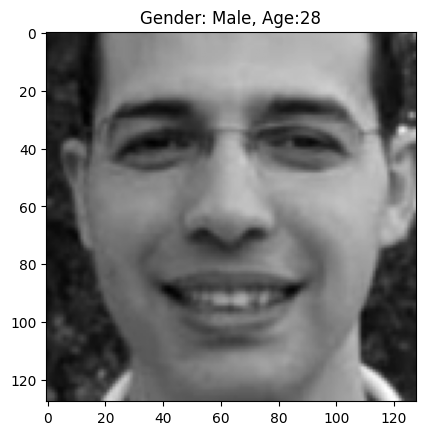

In [41]:
print(f"Predicted gender:\t {pred_gender}\t Predicted Age:\t {pred_age}")
plt.title(f"Gender: {pred_gender}, Age:{pred_age}")
plt.imshow(x[image_index].reshape(128,128),cmap='gray')
plt.show()

Original Gender: 	Female 	 Original Age: 	23
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Predicted Gender: 	Female	 Predicted Age 	27


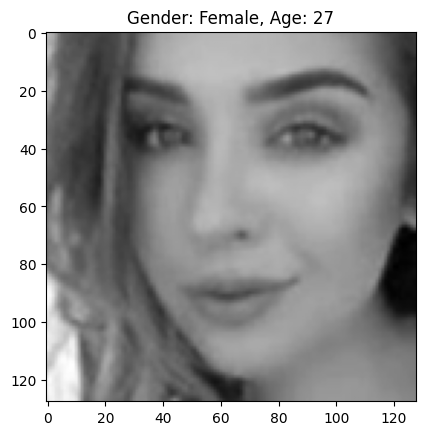

In [45]:
image_index = 35
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(x[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]  
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(x[image_index].reshape(128,128), cmap='gray') 
plt.show()

In [ ]:
image_index = 1
print(f"Original Gender: \t{gender_dict[y_gender[image_index]]} \t Original Age: \t{y_age[image_index]}")

pred = model.predict(x[image_index].reshape(1,128,128,1))
pred_gender = gender_dict[int(round(pred[0][0][0]))]  
pred_age = round(pred[1][0][0])
print(f"Predicted Gender: \t{pred_gender}\t Predicted Age \t{pred_age}")
plt.title(f'Gender: {pred_gender}, Age: {pred_age}')
plt.imshow(x[image_index].reshape(128,128), cmap='gray') 
plt.show()  

NameError: name 'gender_dict' is not defined